In [7]:
import h5py

print("Checking TRAIN...")
with h5py.File("/content/drive/MyDrive/morph_project/processed/train.h5", "r") as f:
    print("X_train:", f["X"].shape)
    print("y_train:", f["y"].shape)

print("\nChecking TEST...")
with h5py.File("/content/drive/MyDrive/morph_project/processed/test.h5", "r") as f:
    print("X_test:", f["X"].shape)
    print("y_test:", f["y"].shape)


Checking TRAIN...
X_train: (7177, 224, 224, 3)
y_train: (7177,)

Checking TEST...
X_test: (1803, 224, 224, 3)
y_test: (1803,)


In [8]:
!rm -f "/content/drive/MyDrive/morph_project/processed/X_train.npy"
!rm -f "/content/drive/MyDrive/morph_project/processed/y_train.npy"
!rm -f "/content/drive/MyDrive/morph_project/processed/X_test.npy"
!rm -f "/content/drive/MyDrive/morph_project/processed/y_test.npy"
!rm -f "/content/drive/MyDrive/morph_project/processed/stats.npz"
!rm -rf "/content/drive/MyDrive/morph_project/processed/batch_X_*"
!rm -rf "/content/drive/MyDrive/morph_project/processed/batch_y_*"



In [9]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import h5py
import numpy as np
import timm
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [10]:
# --- SNIPPET 2: HDF5 Dataset loader + sampler + dataloaders ---

import h5py
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import random

TRAIN_H5 = "/content/drive/MyDrive/morph_project/processed/train.h5"
TEST_H5  = "/content/drive/MyDrive/morph_project/processed/test.h5"

class H5Dataset(Dataset):
    def __init__(self, h5_path, train=False, augment_prob=0.5):
        self.h5 = h5py.File(h5_path, "r")
        self.X = self.h5["X"]    # shape: (N,224,224,3), dtype=float32, already standardized
        self.y = self.h5["y"]
        self.train = train
        self.augment_prob = augment_prob

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        img = self.X[idx]            # HWC, float32, standardized
        label = int(self.y[idx])

        # convert to torch tensor and CHW
        img_t = torch.from_numpy(img).permute(2,0,1).float()

        # simple augmentations on tensor (safe because dataset standardized)
        if self.train:
            if random.random() < self.augment_prob:
                # horizontal flip
                img_t = torch.flip(img_t, dims=[2])
            if random.random() < (self.augment_prob * 0.3):
                # small rotation: -10 to +10 degrees (implemented via torchvision if available)
                angle = random.uniform(-10, 10)
                # use torchvision if present, otherwise skip rotate to keep dependency-free
                try:
                    import torchvision.transforms.functional as TF
                    img_t = TF.rotate(img_t, angle=angle, resample=False, expand=False)
                except Exception:
                    pass

        return img_t, torch.tensor(label, dtype=torch.long)

# instantiate datasets
train_ds = H5Dataset(TRAIN_H5, train=True, augment_prob=0.5)
test_ds  = H5Dataset(TEST_H5, train=False, augment_prob=0.0)

print("Dataset sizes — train:", len(train_ds), " test:", len(test_ds))

# Create WeightedRandomSampler for imbalance
train_labels = np.array(train_ds.h5["y"][:])
class_counts = np.bincount(train_labels)
print("Class counts (train):", class_counts)

class_weights = 1.0 / class_counts
sample_weights = class_weights[train_labels]
sample_weights = torch.tensor(sample_weights, dtype=torch.double)
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# dataloaders
train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler, num_workers=4, pin_memory=True)
val_loader   = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

print("Dataloaders ready — train batches:", len(train_loader), " val batches:", len(val_loader))


Dataset sizes — train: 7177  test: 1803
Class counts (train): [5946 1231]
Dataloaders ready — train batches: 225  val batches: 57


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [11]:
# --- SNIPPET 3: EfficientNet model, loss fn, optimizer, scheduler ---

import timm

# Create EfficientNet-B3
model = timm.create_model(
    "tf_efficientnet_b3_ns",
    pretrained=True,     # ImageNet pretrained backbone helps finetuning
    num_classes=2
).to(device)

# class weights from earlier
AU_count = class_counts[0]
TP_count = class_counts[1]
total = AU_count + TP_count

weight_au = total / (2 * AU_count)
weight_tp = total / (2 * TP_count)

class_weights = torch.tensor([weight_au, weight_tp], device=device, dtype=torch.float32)
print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

scaler = torch.cuda.amp.GradScaler()

print("Model + loss + optimizer + scheduler ready.")


/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name tf_efficientnet_b3_ns to current tf_efficientnet_b3.ns_jft_in1k.
  model = create_fn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Class weights: tensor([0.6035, 2.9151], device='cuda:0')
Model + loss + optimizer + scheduler ready.


/tmp/ipython-input-3899265162.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [12]:
# --- SNIPPET 4: Training loop for EfficientNet ---

import time

def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def validate(model, loader, criterion):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * labels.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


# ---------------- training driver ----------------

EPOCHS = 10
best_val_acc = 0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

save_path = "/content/drive/MyDrive/morph_project/models/efficientnet_b3_retrained.pth"

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
    val_loss, val_acc = validate(model, val_loader, criterion)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"\nEpoch {epoch}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc*100:.2f}%")
    print(f"Time: {time.time() - t0:.1f} sec")

    # save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path)
        print(f"🔥 Saved BEST model (val acc: {val_acc*100:.2f}%) to:", save_path)

print("\nTraining complete!")


/tmp/ipython-input-3564138773.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Epoch 1/10
Train Loss: 0.6862 | Train Acc: 68.05%
Val   Loss: 1.4039 | Val   Acc: 59.90%
Time: 157.6 sec
🔥 Saved BEST model (val acc: 59.90%) to: /content/drive/MyDrive/morph_project/models/efficientnet_b3_retrained.pth

Epoch 2/10
Train Loss: 0.2855 | Train Acc: 83.15%
Val   Loss: 1.0306 | Val   Acc: 71.05%
Time: 89.9 sec
🔥 Saved BEST model (val acc: 71.05%) to: /content/drive/MyDrive/morph_project/models/efficientnet_b3_retrained.pth

Epoch 3/10
Train Loss: 0.1916 | Train Acc: 88.46%
Val   Loss: 0.9975 | Val   Acc: 72.49%
Time: 91.2 sec
🔥 Saved BEST model (val acc: 72.49%) to: /content/drive/MyDrive/morph_project/models/efficientnet_b3_retrained.pth

Epoch 4/10
Train Loss: 0.1470 | Train Acc: 91.38%
Val   Loss: 0.8959 | Val   Acc: 76.87%
Time: 89.4 sec
🔥 Saved BEST model (val acc: 76.87%) to: /content/drive/MyDrive/morph_project/models/efficientnet_b3_retrained.pth

Epoch 5/10
Train Loss: 0.1147 | Train Acc: 93.12%
Val   Loss: 0.8410 | Val   Acc: 78.92%
Time: 89.9 sec
🔥 Saved BEST m

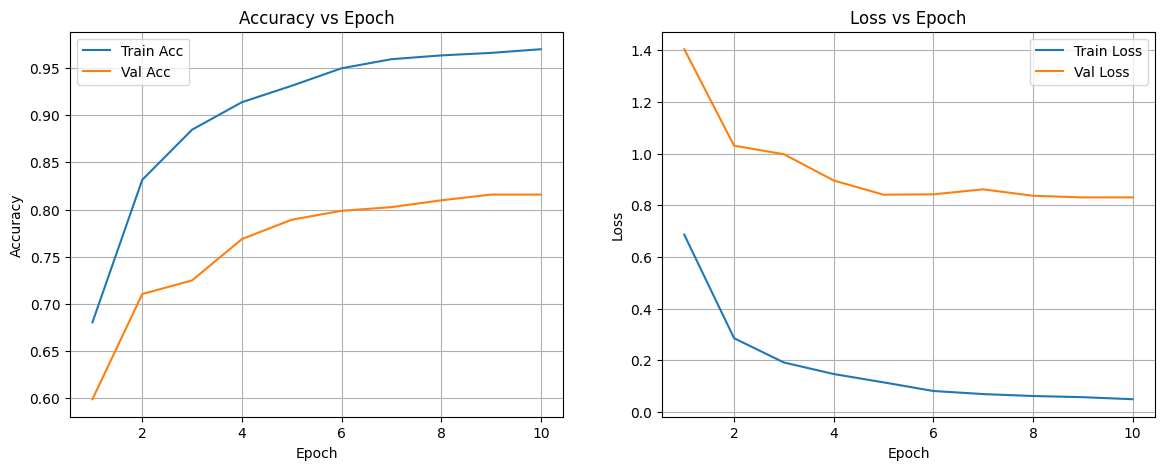

In [13]:
# --- SNIPPET 5: Plot accuracy and loss curves ---

epochs = range(1, len(history["train_acc"]) + 1)

plt.figure(figsize=(14,5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid()

plt.show()


Confusion Matrix:
 [[1287  202]
 [ 130  184]]


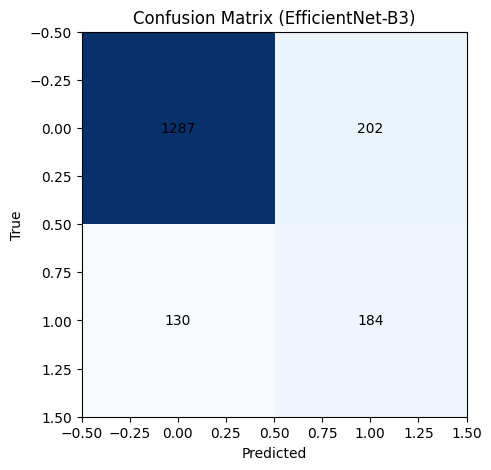


Classification Report:
              precision    recall  f1-score   support

      AU (0)       0.91      0.86      0.89      1489
      TP (1)       0.48      0.59      0.53       314

    accuracy                           0.82      1803
   macro avg       0.69      0.73      0.71      1803
weighted avg       0.83      0.82      0.82      1803



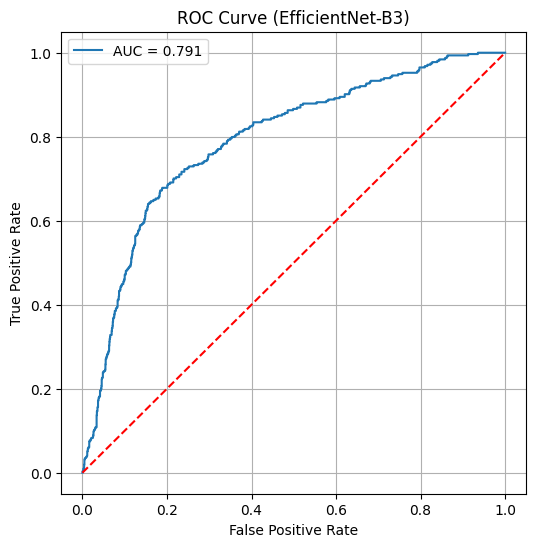


Final Test AUC: 0.791


In [14]:
# --- SNIPPET 6: Final Test Evaluation for EfficientNet ---

model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for imgs, labels in val_loader:   # using val_loader = test set
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)

        preds = outputs.argmax(1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs[:,1].cpu().numpy())   # probability of TP class


# ---------------- Confusion Matrix ----------------
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(5,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (EfficientNet-B3)")
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.show()


# ---------------- Classification Report ----------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["AU (0)", "TP (1)"]))


# ---------------- ROC Curve + AUC ----------------
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "r--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (EfficientNet-B3)")
plt.legend()
plt.grid()
plt.show()

print(f"\nFinal Test AUC: {roc_auc:.3f}")


In [18]:
# ============================
# FINAL EFFICIENTNET INFERENCE
# ============================

import torch
import torch.nn as nn
import timm
import cv2
import numpy as np
from google.colab import files

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# -------------------------
# Universal Preprocessing
# -------------------------

MEAN = -2.6647588e-06
STD  = 0.9996273

def preprocess_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize
    img = cv2.resize(img, (224, 224))

    # Denoise
    img = cv2.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21)

    # Histogram Equalization (Y channel)
    img_yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    img_yuv[:,:,0] = cv2.equalizeHist(img_yuv[:,:,0])
    img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

    # Sharpen
    kernel = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]])
    img = cv2.filter2D(img, -1, kernel)

    img = img.astype(np.float32) / 255.0
    img = (img - MEAN) / (STD + 1e-7)   # SAME STANDARDIZATION AS HDF5

    img = torch.tensor(img).permute(2,0,1).float().unsqueeze(0)
    return img.to(device)

# -------------------------
# Load Model
# -------------------------

model_path = "/content/drive/MyDrive/morph_project/models/efficientnet_b3_retrained.pth"

model = timm.create_model(
    "tf_efficientnet_b3_ns",
    pretrained=False,
    num_classes=2
)

model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

print("✅ Model Loaded Successfully!")

# -------------------------
# Predict Function
# -------------------------

def predict_image(path):
    img = preprocess_image(path)

    with torch.no_grad():
        out = model(img)
        probs = torch.softmax(out, dim=1)[0]

    pred = probs.argmax().item()
    confidence = float(probs[pred] * 100)

    label = "Authentic (AU, 0)" if pred == 0 else "Tampered (TP, 1)"

    print("\n===========================")
    print(f"IMAGE: {path}")
    print(f"PREDICTION: {label}")
    print(f"CONFIDENCE: {confidence:.2f}%")
    print("===========================\n")

# -------------------------
# Upload + Predict
# -------------------------

uploaded = files.upload()

for name in uploaded.keys():
    predict_image(name)


Device: cuda
✅ Model Loaded Successfully!


Saving img0.1.png to img0.1.png

IMAGE: img0.1.png
PREDICTION: Tampered (TP, 1)
CONFIDENCE: 85.35%

